#### [자동차 연비 관련 분석] <hr>  
- 데이터 : auto_mpg.csv
- 특징
    - 1993년도 미국에 자동차 연비 분석을 위해 수집된 데이터
    - 9개의 컬럼/변수 (1개 타겟, 8개 피쳐)
    - 다변량 데이터셋
---

[1] 모듈 로딩 및 데이터 준비 <hr>

In [1]:
# 모듈 로딩
import pandas as pd

In [2]:
# 데이터 선정
DATA_FILE = r'../DATA/auto_mpg.csv'

[2] CSV >>> DataFrame 로딩 및 기본 정보 확인 <hr>

In [3]:
# DF 인스턴스 생성
# [기본] -> header=0, sep=','
mpg_df = pd.read_csv(DATA_FILE)

In [4]:
# 기본 요약 정보
mpg_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [5]:
# 모든 컬럼의 기초 통계값 확인
display(mpg_df.describe(include='all'))

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
count,398.000000,398.000000,398.000000,398,398.000000,398.000000,398.000000,398.000000,398
unique,NaN,NaN,NaN,94,NaN,NaN,NaN,NaN,305
top,NaN,NaN,NaN,150,NaN,NaN,NaN,NaN,ford pinto
freq,NaN,NaN,NaN,22,NaN,NaN,NaN,NaN,6
mean,23.514573,5.454774,193.425879,NaN,2970.424623,15.568090,76.010050,1.572864,NaN
std,7.815984,1.701004,104.269838,NaN,846.841774,2.757689,3.697627,0.802055,NaN
min,9.000000,3.000000,68.000000,NaN,1613.000000,8.000000,70.000000,1.000000,NaN
25%,17.500000,4.000000,104.250000,NaN,2223.750000,13.825000,73.000000,1.000000,NaN
50%,23.000000,4.000000,148.500000,NaN,2803.500000,15.500000,76.000000,1.000000,NaN
75%,29.000000,8.000000,262.000000,NaN,3608.000000,17.175000,79.000000,2.000000,NaN


In [6]:
# 데이터 일부 확인 head()/tail()
mpg_df.head(3)

# <class 'pandas.core.frame.DataFrame'>
# RangeIndex: 398 entries, 0 to 397
# Data columns (total 9 columns):
#  #   Column        Non-Null Count  Dtype  
# ---  ------        --------------  -----  
#  0   mpg           398 non-null    float64
#  1   cylinders     398 non-null    int64      => 범주형 데이터
#  2   displacement  398 non-null    float64
#  3   horsepower    398 non-null    object     => '130' 또는 믹싱
#  4   weight        398 non-null    int64  
#  5   acceleration  398 non-null    float64
#  6   model year    398 non-null    int64      => 년도 => 좀 더 확인 필요 정수 X
#  7   origin        398 non-null    int64      => 제조국 / 범주형
#  8   car name      398 non-null    object 
# dtypes: float64(3), int64(4), object(2)
# memory usage: 28.1+ KB

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite


[3] 기초 전처리<hr>
- 결측치 / 중복값 체크
- 컬럼별 자료형 일치

In [7]:
# [3-1] 결측치 : isna() / isnull() -> 원소마다 검사
mpg_df.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [8]:
# [3-2] 중복 데이터 검사 : duplicated()
mpg_df.duplicated().sum()

np.int64(0)

In [9]:
# [3-3] 컬럼별 자료형 변환 - horsepower
# => 마력은 숫자 데이터인데 이상한 ? 데이터 : 이상치
# => horsepower 컬럼 object >>> int

# 이상치가 있는 행 번호 추출
drop_index = mpg_df[mpg_df['horsepower'] == '?'].index

# 이상치 있는 행 삭제
mpg_df = mpg_df.drop(index=drop_index).reset_index(drop=True)

# object >>> int
mpg_df['horsepower'] = mpg_df['horsepower'].astype(int)

In [10]:
# [3-3] 컬럼별 자료형 변환 - model year, cylinders, origin 컬럼
# model_year, cylinders, origin int64 >>> 범주형
# 고유값 ------------------------------------------------------
# - 값의 종류
# - Series에 제공되는 메서드 unique()
# -------------------------------------------------------------
# 고유값 확인 즉, 컬럼별 값의 종류 체크
for col in ['model year', 'cylinders', 'origin']:
    print(f"{col:10} ==> {mpg_df[col].unique()}")

model year ==> [70 71 72 73 74 75 76 77 78 79 80 81 82]
cylinders  ==> [8 4 6 3 5]
origin     ==> [1 3 2]


In [11]:
# int64 >>> 범주형 형변환
for col in ['model year', 'cylinders', 'origin']:
    mpg_df[col] = mpg_df[col].astype('category')

In [12]:
# [3-4] 컬럼별 자료형 변환 - 연속형/수치형 >>> 범주형
# - 숫자값을 일정 구간으로 나누어서 이해가 쉽도록 만들어주는 방법
# - 예) 연령대 : 1, 3, 4, 6, 12 ==> 10대, 20대, 30대 ==> 청년, 중년, 장년, 노년
# - 함수 : pandas.cut()
# 마력/출력 => 저출력, 일반출력, 고출력 : 범위 조사
ret_sr = pd.cut(x=mpg_df['horsepower'], 
                bins=3,
                labels=['저출력', '일반출력', '고출력'])

# 현재 DF에 새로운 컬럼으로 추가
mpg_df['horsepower_label'] = ret_sr

mpg_df.head(3)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name,horsepower_label
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu,일반출력
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320,일반출력
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite,일반출력


In [13]:
# 자료형 확인
mpg_df.dtypes

mpg                  float64
cylinders           category
displacement         float64
horsepower             int64
weight                 int64
acceleration         float64
model year          category
origin              category
car name              object
horsepower_label    category
dtype: object

[4] 연비 mpg 컬럼과 관련성이 있는 속성/피쳐 <hr>
- 타겟 컬럼/변수 : mpg
- 피쳐 컬럼/속성 : 나머지 컬럼
- 상관계수  활용 
    - 컬럼들의 관계/선형 정도를 수치화
    - 값의 범위가 -1 ~ 1
    - 음의 상관관계 / 양의 상관관계
    - ★ 인과관계가 아님
    - ★ 완벽한 선형이 아닌경우 -1/1에 가까운 값이 나오지 않을 수도 있음
    - ★ 시각화를 통해서 컬럼들을 결정지어야함

In [14]:
# mpg 컬럼과 관련성이 있는 정도 체크 : corr()
mpg_df.corr(numeric_only=True)

,mpg,displacement,horsepower,weight,acceleration
mpg,1.000000,-0.805127,-0.778427,-0.832244,0.423329
displacement,-0.805127,1.000000,0.897257,0.932994,-0.543800
horsepower,-0.778427,0.897257,1.000000,0.864538,-0.689196
weight,-0.832244,0.932994,0.864538,1.000000,-0.416839
acceleration,0.423329,-0.543800,-0.689196,-0.416839,1.000000


In [18]:
# mpg 컬럼만 추출
corr_sr = mpg_df.corr(numeric_only=True)['mpg'].abs()
corr_sr.index[1:]

Index(['displacement', 'horsepower', 'weight', 'acceleration'], dtype='object')

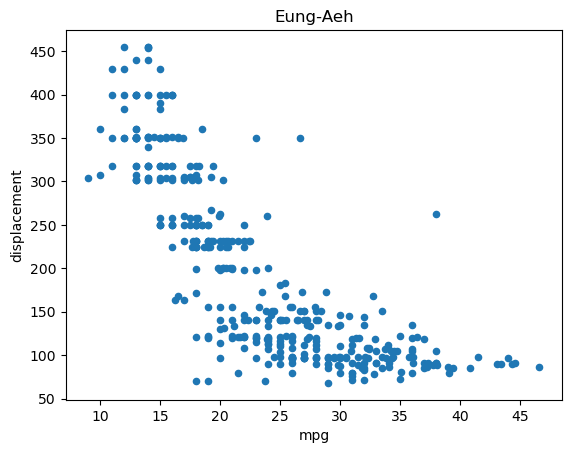

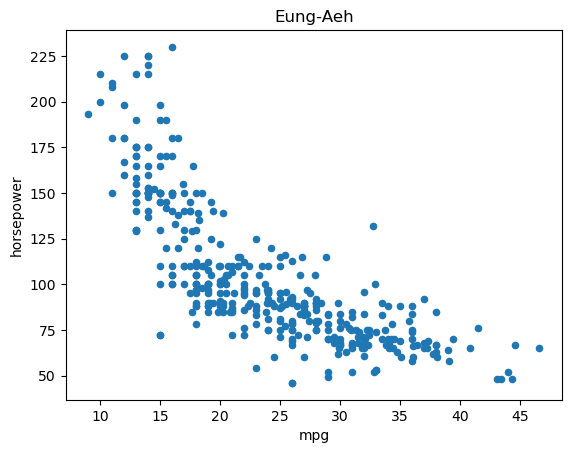

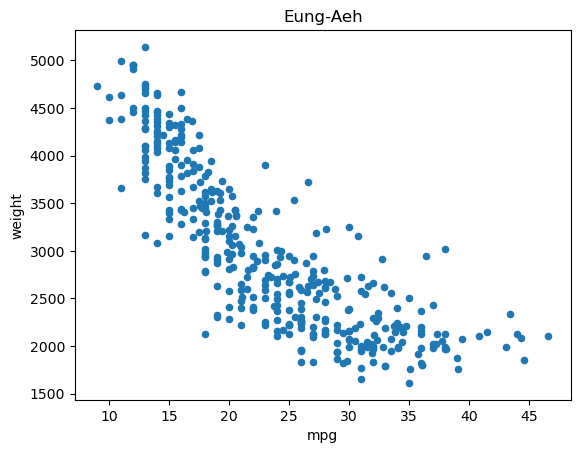

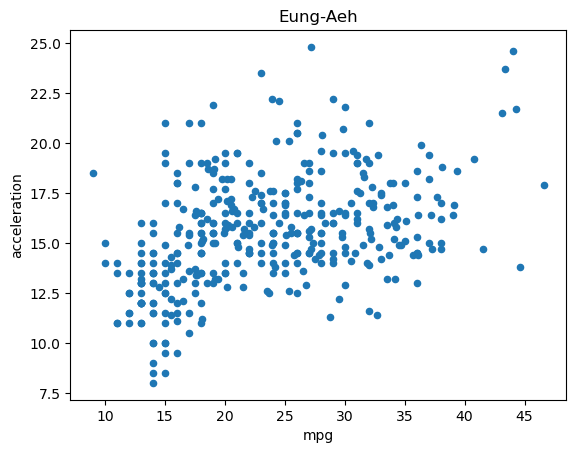

In [21]:
# mpg 칼럼과 다른 컬럼과의 관계 시각화
for col in corr_sr.index[1:]:
    mpg_df.plot(x='mpg', y=col, kind='scatter', title='Eung-Aeh')